In [10]:
import numpy as np

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

In [7]:
import matplotlib.pyplot as plt

def plot_sample(footdata, comdata, ax=None, title=None):

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

    xr, yr, zr = footdata[:,0], footdata[:,2], footdata[:,1]
    xl, yl, zl = footdata[:,3], footdata[:,5], footdata[:,4]

    ax.plot(xr, yr, zr, label="Right foot")
    ax.plot(xl, yl, zl, label="Left foot")

    xc, yc, zc = comdata[:,0], comdata[:,2], comdata[:,1]

    ax.plot(xc, yc, zc, label="CoM", linewidth=2, linestyle="--")

    # optional: highlight start point
    ax.scatter(xc[0], yc[0], zc[0], s=50, marker="o", label="CoM start")

    # ---- labels ----
    ax.set_xlabel("Forward (x)")
    ax.set_ylabel("Lateral (y)")
    ax.set_zlabel("Vertical (z)")

    if title:
        ax.set_title(title)

    ax.legend()
    set_axes_equal(ax)

    return ax

Generating sample 1/10
height_factor: 0.9852704262169025
Generating sample 2/10
height_factor: 1.0609260363843824
Generating sample 3/10
height_factor: 0.916449480376167
Generating sample 4/10
height_factor: 1.1318419457315447
Generating sample 5/10
height_factor: 1.0019454374350911
Generating sample 6/10
height_factor: 1.066416600465823
Generating sample 7/10
height_factor: 0.9783198779138472
Generating sample 8/10
height_factor: 0.9513269433912465
Generating sample 9/10
height_factor: 1.146405988870572
Generating sample 10/10
height_factor: 1.0286147979209275
Dataset saved to dataset.npz
tensor([1.6750, 1.8036, 1.5580, 1.9241, 1.7033, 1.8129, 1.6631, 1.6173, 1.9489,
        1.7486])


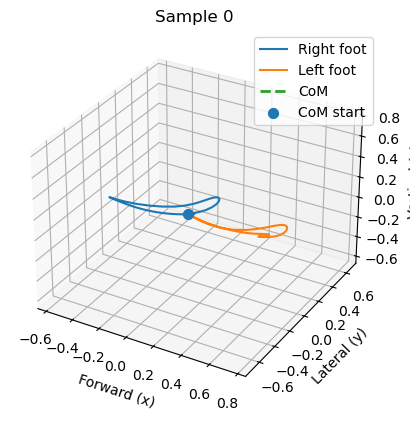

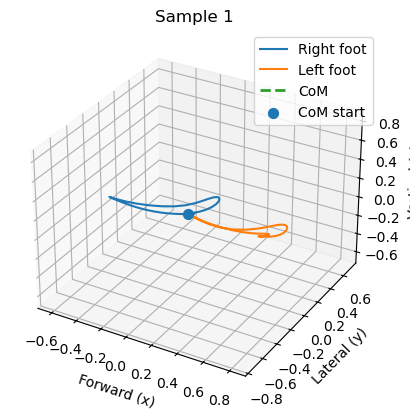

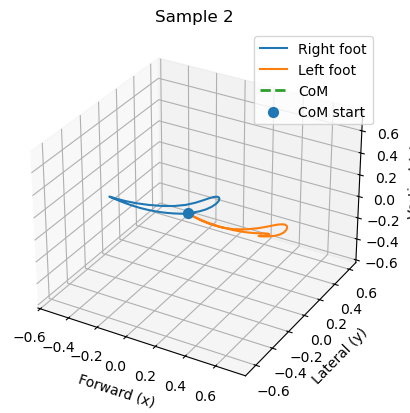

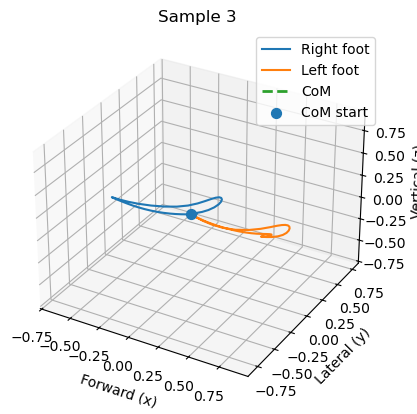

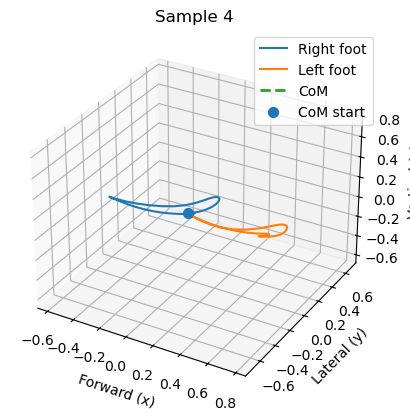

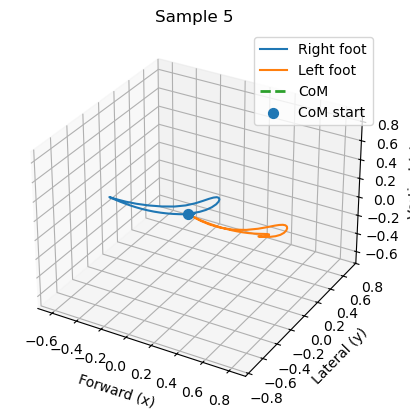

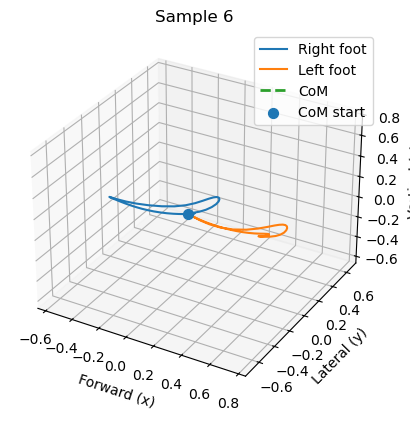

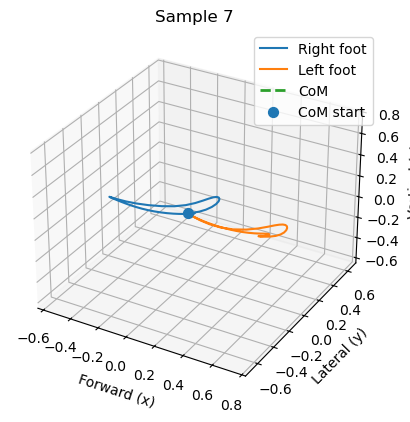

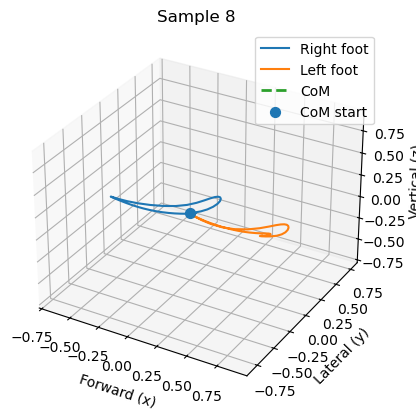

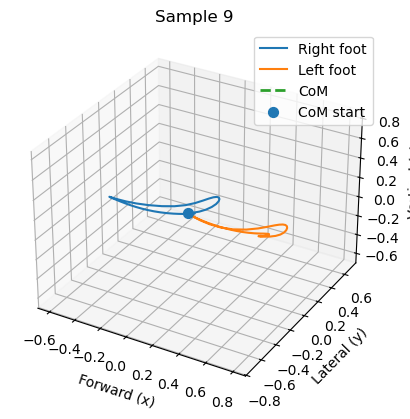

In [9]:
from generatedata import generate_dataset
generate_dataset(10, "normal.mot")

import torch
import numpy as np
data = np.load("dataset.npz")

foot = torch.tensor(data["foot"], dtype=torch.float32)
com  = torch.tensor(data["com"], dtype=torch.float32)
height = torch.tensor(data["height"], dtype=torch.float32)

print(height.squeeze())

for i in range(len(foot)):
    plot_sample(foot[i].numpy(), com[i].numpy(), title=f"Sample {i}")
    plt.show()